# 01 — Exploración de Datos
**Proyecto:** NLP Disaster Tweets Classification  
**Curso:** Fundamentos de Deep Learning — Universidad de Antioquia  
**Autor:** Assandry Barón Rodríguez  

Este notebook realiza el **Análisis Exploratorio de Datos (EDA)** sobre el dataset
de Kaggle *"Natural Language Processing with Disaster Tweets"*.  
El objetivo es entender la distribución, calidad y características antes de diseñar el pipeline de modelado.

---
**Contenido**
1. Configuración del entorno (Drive + librerías)
2. Carga del dataset
3. Vista general y estadísticas
4. Distribución de clases
5. Análisis de longitud de tweets
6. Análisis de keywords y localización
7. Nube de palabras por clase
8. Conclusiones del EDA


## 1. Configuración del Entorno

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# CAMBIA este path si tu carpeta tiene otro nombre
BASE_PATH  = '/content/drive/MyDrive/NLP_Disaster_Tweets'
DATA_PATH  = os.path.join(BASE_PATH, 'data')
MODEL_PATH = os.path.join(BASE_PATH, 'models')

os.makedirs(MODEL_PATH, exist_ok=True)

print("Verificando archivos fuente ...")
for f in ['train.csv', 'test.csv', 'sample_submission.csv']:
    full   = os.path.join(DATA_PATH, f)
    status = '✅' if os.path.exists(full) else '❌  NO ENCONTRADO'
    print(f'  {status}  {f}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Verificando archivos fuente ...
  ✅  train.csv
  ✅  test.csv
  ✅  sample_submission.csv


In [3]:
# Instalación de librerías
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip_install('wordcloud')
print('✅ Librerías listas')


✅ Librerías listas


In [4]:
# Imports
import re
import warnings
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from wordcloud   import WordCloud

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 140)
SEED = 42
np.random.seed(SEED)

print('✅ Imports correctos')


✅ Imports correctos


## 2. Carga del Dataset

In [5]:
train_df = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))

print(f'Train : {train_df.shape[0]:,} filas × {train_df.shape[1]} columnas')
print(f'Test  : {test_df.shape[0]:,}  filas × {test_df.shape[1]} columnas')
print()
print('Columnas train:', list(train_df.columns))
print('Columnas test :', list(test_df.columns))


Train : 7,613 filas × 5 columnas
Test  : 3,263  filas × 4 columnas

Columnas train: ['id', 'keyword', 'location', 'text', 'target']
Columnas test : ['id', 'keyword', 'location', 'text']


In [6]:
# Primeras filas
train_df.head(6)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,1


## 3. Vista General y Estadísticas

In [7]:
print('=' * 55)
print('INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO')
print('=' * 55)
train_df.info()


INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [8]:
print('Valores nulos por columna (train):')
print(train_df.isnull().sum())
print()
print(f'Porcentaje nulos — keyword  : {train_df["keyword"].isnull().mean()*100:.1f}%')
print(f'Porcentaje nulos — location : {train_df["location"].isnull().mean()*100:.1f}%')
print(f'Porcentaje nulos — text     : {train_df["text"].isnull().mean()*100:.1f}%')


Valores nulos por columna (train):
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Porcentaje nulos — keyword  : 0.8%
Porcentaje nulos — location : 33.3%
Porcentaje nulos — text     : 0.0%


In [9]:
print('Tweets duplicados (texto exacto):', train_df['text'].duplicated().sum())
print()
print('Estadísticas de la columna target:')
print(train_df['target'].describe())


Tweets duplicados (texto exacto): 110

Estadísticas de la columna target:
count    7613.00000
mean        0.42966
std         0.49506
min         0.00000
25%         0.00000
50%         0.00000
75%         1.00000
max         1.00000
Name: target, dtype: float64


## 4. Distribución de Clases

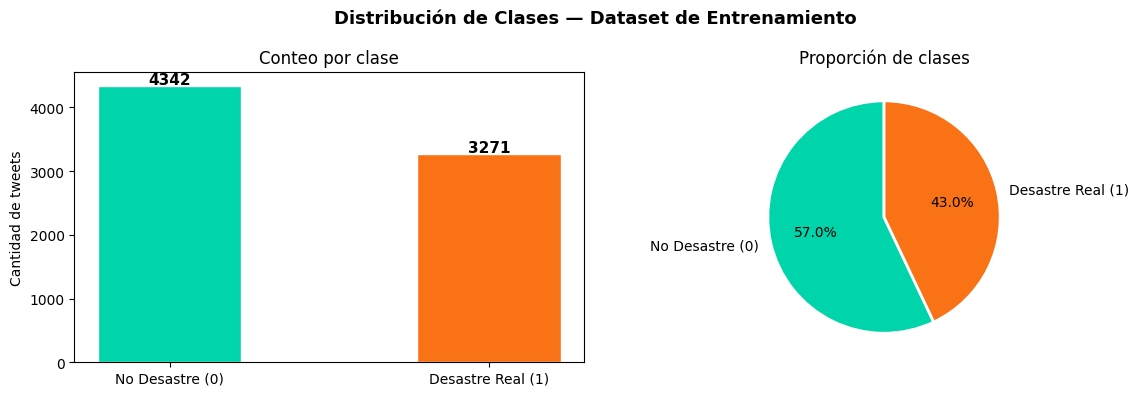

Clase 0 (No desastre): 4,342 tweets (57.0%)
Clase 1 (Desastre)   : 3,271 tweets (43.0%)
Ratio desbalance     : 1.33 : 1


In [10]:
counts = train_df['target'].value_counts()
labels = ['No Desastre (0)', 'Desastre Real (1)']
colors_  = ['#00d4aa', '#f97316']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribución de Clases — Dataset de Entrenamiento',
             fontsize=13, fontweight='bold')

# Barras
axes[0].bar(labels, [counts[0], counts[1]],
            color=colors_, edgecolor='white', width=0.45)
axes[0].set_ylabel('Cantidad de tweets')
axes[0].set_title('Conteo por clase')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 25, str(v), ha='center', fontweight='bold', fontsize=11)

# Pie
axes[1].pie([counts[0], counts[1]], labels=labels, colors=colors_,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'eda_class_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Clase 0 (No desastre): {counts[0]:,} tweets ({counts[0]/len(train_df)*100:.1f}%)')
print(f'Clase 1 (Desastre)   : {counts[1]:,} tweets ({counts[1]/len(train_df)*100:.1f}%)')
print(f'Ratio desbalance     : {counts[0]/counts[1]:.2f} : 1')


## 5. Análisis de Longitud de Tweets

In [11]:
train_df['char_len'] = train_df['text'].apply(len)
train_df['word_len'] = train_df['text'].apply(lambda x: len(str(x).split()))

print('Estadísticas de longitud (palabras):')
print(train_df.groupby('target')['word_len'].describe().round(2))


Estadísticas de longitud (palabras):
         count   mean   std  min   25%   50%   75%   max
target                                                  
0       4342.0  14.70  6.16  1.0  10.0  15.0  19.0  31.0
1       3271.0  15.17  5.10  2.0  11.0  15.0  19.0  30.0


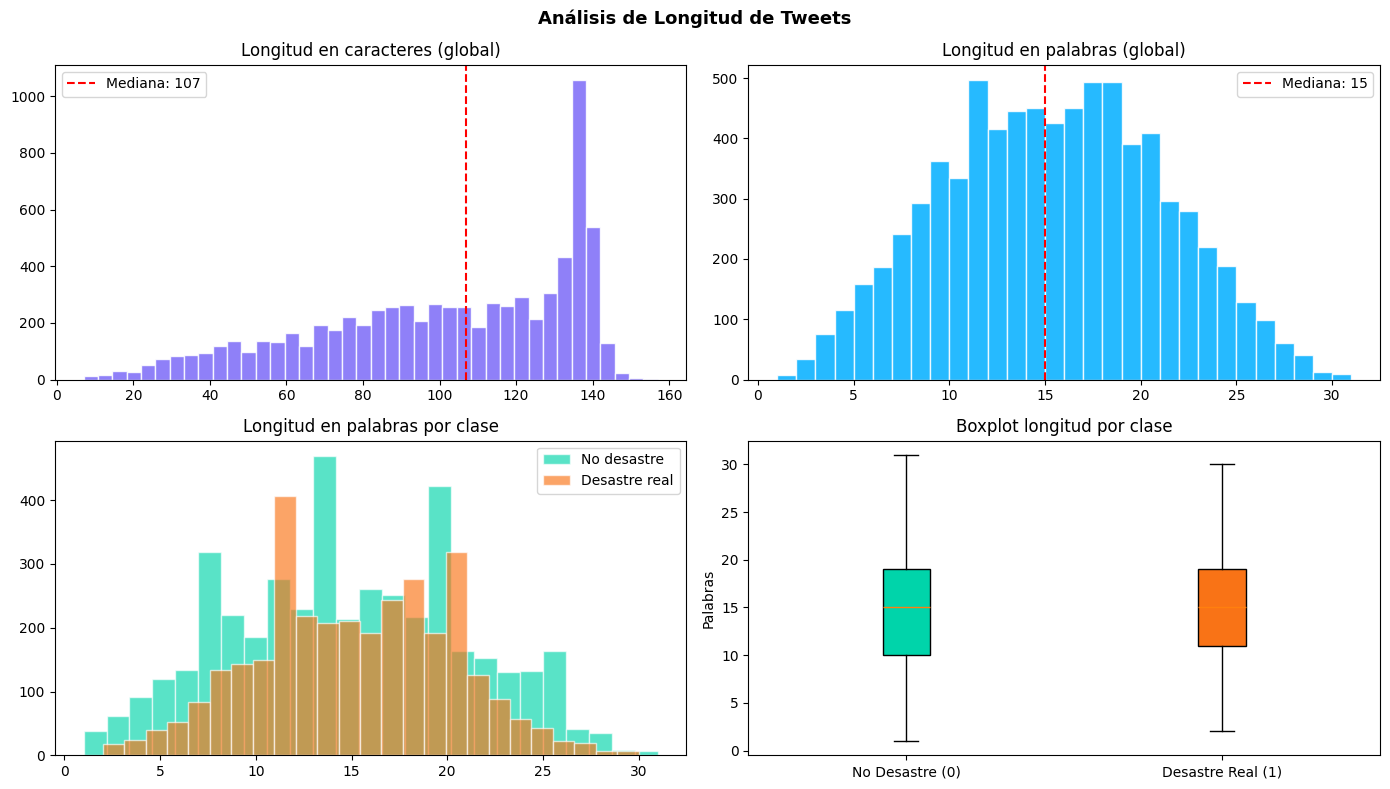

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Análisis de Longitud de Tweets', fontsize=13, fontweight='bold')

# Histograma caracteres
axes[0][0].hist(train_df['char_len'], bins=40, color='#7c6af7', alpha=0.85, edgecolor='white')
axes[0][0].axvline(train_df['char_len'].median(), color='red', ls='--', lw=1.5,
               label=f'Mediana: {train_df["char_len"].median():.0f}')
axes[0][0].set_title('Longitud en caracteres (global)'); axes[0][0].legend()

# Histograma palabras
axes[0][1].hist(train_df['word_len'], bins=30, color='#00aeff', alpha=0.85, edgecolor='white')
axes[0][1].axvline(train_df['word_len'].median(), color='red', ls='--', lw=1.5,
               label=f'Mediana: {train_df["word_len"].median():.0f}')
axes[0][1].set_title('Longitud en palabras (global)'); axes[0][1].legend()

# Por clase — palabras
for target, color, label in [(0,'#00d4aa','No desastre'), (1,'#f97316','Desastre real')]:
    subset = train_df[train_df['target'] == target]['word_len']
    axes[1][0].hist(subset, bins=25, color=color, alpha=0.65, label=label, edgecolor='white')
axes[1][0].set_title('Longitud en palabras por clase')
axes[1][0].legend()

# Boxplot por clase
data_box = [
    train_df[train_df['target'] == 0]['word_len'],
    train_df[train_df['target'] == 1]['word_len']
]
bp = axes[1][1].boxplot(data_box, patch_artist=True,
                        labels=['No Desastre (0)', 'Desastre Real (1)'])
for patch, color in zip(bp['boxes'], ['#00d4aa', '#f97316']):
    patch.set_facecolor(color)
axes[1][1].set_title('Boxplot longitud por clase')
axes[1][1].set_ylabel('Palabras')

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'eda_tweet_lengths.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## 6. Análisis de Keywords y Localización

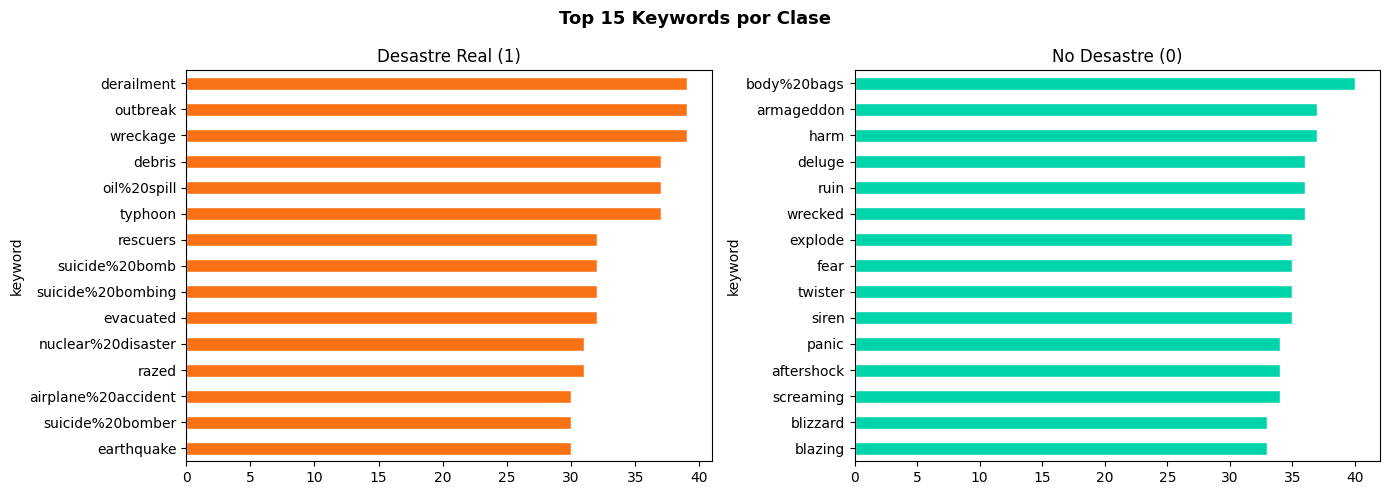

In [13]:
# Top keywords por clase
kw_dis    = train_df[train_df['target'] == 1]['keyword'].dropna()
kw_no_dis = train_df[train_df['target'] == 0]['keyword'].dropna()

top_d  = kw_dis.value_counts().head(15)
top_nd = kw_no_dis.value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top 15 Keywords por Clase', fontsize=13, fontweight='bold')

top_d.plot(kind='barh', ax=axes[0], color='#f97316', edgecolor='white')
axes[0].set_title('Desastre Real (1)'); axes[0].invert_yaxis()

top_nd.plot(kind='barh', ax=axes[1], color='#00d4aa', edgecolor='white')
axes[1].set_title('No Desastre (0)'); axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'eda_top_keywords.png'),
            dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Top 10 localizaciones
top_loc = train_df['location'].dropna().value_counts().head(10)
print('Top 10 localizaciones más frecuentes:')
print(top_loc)
print(f'\nLocalizaciones únicas: {train_df["location"].nunique()}')


Top 10 localizaciones más frecuentes:
location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Name: count, dtype: int64

Localizaciones únicas: 3341


# 7. Nube de Palabras por Clase

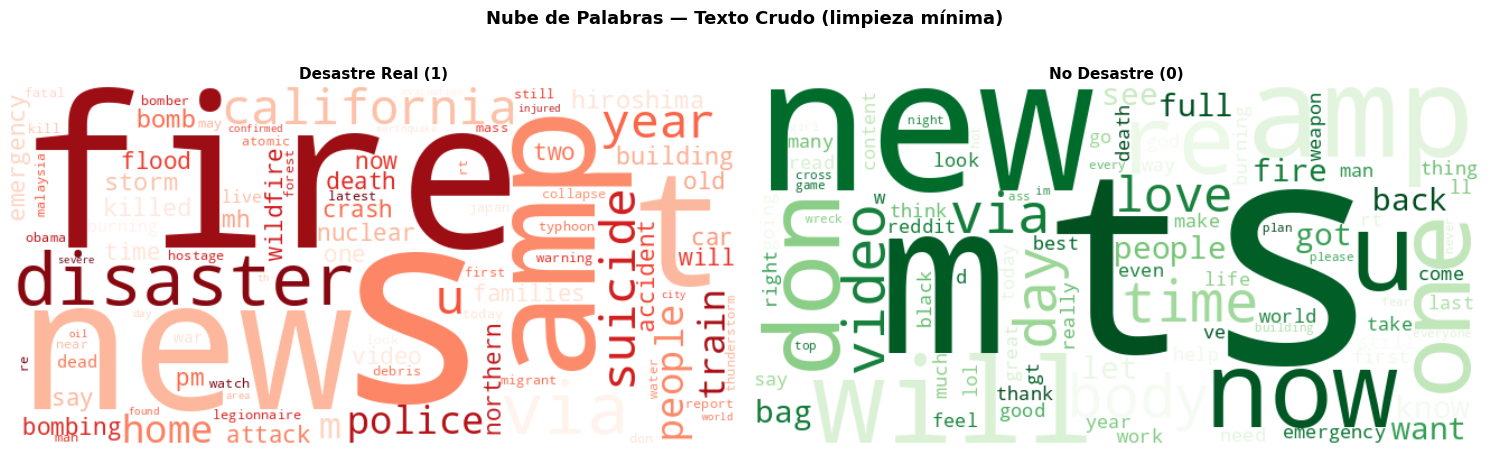

In [15]:
# Limpieza mínima solo para el EDA visual
def quick_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

corpus_dis    = ' '.join(train_df[train_df['target'] == 1]['text'].apply(quick_clean))
corpus_no_dis = ' '.join(train_df[train_df['target'] == 0]['text'].apply(quick_clean))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Nube de Palabras — Texto Crudo (limpieza mínima)', fontsize=13, fontweight='bold')

for ax, corpus, title, cmap in zip(
    axes,
    [corpus_dis, corpus_no_dis],
    ['Desastre Real (1)', 'No Desastre (0)'],
    ['Reds', 'Greens']
):
    wc = WordCloud(width=650, height=320, background_color='white',
                   colormap=cmap, max_words=90,
                   collocations=False).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off'); ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'eda_wordcloud.png'),
            dpi=150, bbox_inches='tight')
plt.show()
